In [ ]:
from google.colab import drive
# Load the data set and unzip it.
drive.mount('/content/drive')
import zipfile
zip_path = '/content/drive/MyDrive/Snake_FeaturedDataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. DATA LOADING & PREPROCESSING


# Load features
features_path = "/content"
X = np.load(os.path.join(features_path, "selected_features.npy"))
y = np.load(os.path.join(features_path, "labels.npy"))

print(f"• Features: {X.shape}")
print(f"• Labels: {y.shape}")
print(f"• Classes: {np.unique(y)}")

• Features: (33117, 500)
• Labels: (33117,)
• Classes: [0. 1.]


In [ ]:
# Apply 3 different pre-processing methods

preprocessing_methods = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

preprocessed_data = {}
for preproc_name, preprocessor in preprocessing_methods.items():
    print(f"   Applying {preproc_name}...")
    preprocessed_data[preproc_name] = preprocessor.fit_transform(X)

print(" Pre-processing completed")

   Applying StandardScaler...
   Applying MinMaxScaler...
   Applying RobustScaler...
 Pre-processing completed


In [ ]:
# 2. DECISION TREE WITH PARAMETER TUNING

# Define Decision Tree varieties with different hyperparameters
dt_varieties = {
    'DT_Default': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'DT_Regularized': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 7],
            'min_samples_split': [10, 20],
            'min_samples_leaf': [5, 10],
            'max_features': ['sqrt', 'log2']
        }
    },
    'DT_Balanced': {
        'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_impurity_decrease': [0.0, 0.01, 0.1]
        }
    }
}

In [ ]:
# Comprehensive evaluation
results = []
total_combinations = len(preprocessed_data) * len(dt_varieties)
current_combination = 0

print(f"\n TRAINING {total_combinations} DECISION TREE COMBINATIONS...")

for preproc_name, X_processed in preprocessed_data.items():
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )

    for variety_name, variety_config in dt_varieties.items():
        current_combination += 1
        print(f"\n [{current_combination}/{total_combinations}] {variety_name} + {preproc_name}")

        start_time = time.time()

        # Parameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            variety_config['model'],
            variety_config['param_grid'],
            cv=5,
            scoring='f1',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        # Predictions
        y_pred = best_model.predict(X_test)
        y_pred_proba = best_model.predict_proba(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        auc = roc_auc_score(y_test, y_pred_proba[:, 1])

        training_time = time.time() - start_time

        results.append({
            'model_type': 'Decision Tree',
            'variety': variety_name,
            'preprocessing': preproc_name,
            'best_params': grid_search.best_params_,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc_roc': auc,
            'training_time': training_time,
            'model_object': best_model,
            'feature_importance': best_model.feature_importances_
        })

        print(f"    Best params: {grid_search.best_params_}")
        print(f"    Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        print(f"    Time: {training_time:.2f}s")

print(f"\n DECISION TREE EVALUATION COMPLETED!")


 TRAINING 9 DECISION TREE COMBINATIONS...

 [1/9] DT_Default + StandardScaler
Fitting 5 folds for each of 24 candidates, totalling 120 fits
    Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
    Accuracy: 0.6184, F1: 0.6170, AUC: 0.6464
    Time: 1261.88s

 [2/9] DT_Regularized + StandardScaler
Fitting 5 folds for each of 48 candidates, totalling 240 fits
    Best params: {'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20}
    Accuracy: 0.6025, F1: 0.6010, AUC: 0.6489
    Time: 45.97s

 [3/9] DT_Balanced + StandardScaler
Fitting 5 folds for each of 54 candidates, totalling 270 fits
    Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_impurity_decrease': 0.0, 'min_samples_split': 5}
    Accuracy: 0.6182, F1: 0.6167, AUC: 0.6474
    Time: 1192.21s

 [4/9] DT_Default + MinMaxScaler
Fitting 5 folds for each of 24 candidates, totalling 120 fits
    Best params: {'criterion': 'entropy', '

In [ ]:
# 3. COMPREHENSIVE ANALYSIS

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display top models
print("\n TOP PERFORMING DECISION TREE MODELS:")
top_models = results_df.nlargest(5, 'f1')[
    ['variety', 'preprocessing', 'f1', 'accuracy', 'auc_roc', 'training_time']
]
print(top_models.round(4).to_string(index=False))

# Best overall model
best_overall = results_df.loc[results_df['f1'].idxmax()]
print(f"\n BEST OVERALL DECISION TREE:")
print(f"● Variety: {best_overall['variety']}")
print(f"● Pre-processing: {best_overall['preprocessing']}")
print(f"● F1-Score: {best_overall['f1']:.4f}")
print(f"● Accuracy: {best_overall['accuracy']:.4f}")
print(f"● AUC-ROC: {best_overall['auc_roc']:.4f}")

# Analysis by variety
print(f"\n DECISION TREE VARIETY PERFORMANCE:")
variety_performance = results_df.groupby('variety').agg({
    'f1': ['mean', 'max'],
    'accuracy': 'mean',
    'training_time': 'mean'
}).round(4)
print(variety_performance)


 TOP PERFORMING DECISION TREE MODELS:
    variety  preprocessing     f1  accuracy  auc_roc  training_time
 DT_Default StandardScaler 0.6170    0.6184   0.6464      1261.8834
 DT_Default   MinMaxScaler 0.6170    0.6184   0.6464      1223.0323
 DT_Default   RobustScaler 0.6170    0.6184   0.6464      1212.3596
DT_Balanced StandardScaler 0.6167    0.6182   0.6474      1192.2112
DT_Balanced   MinMaxScaler 0.6167    0.6182   0.6474      1239.6547

 BEST OVERALL DECISION TREE:
● Variety: DT_Default
● Pre-processing: StandardScaler
● F1-Score: 0.6170
● Accuracy: 0.6184
● AUC-ROC: 0.6464

 DECISION TREE VARIETY PERFORMANCE:
                    f1         accuracy training_time
                  mean     max     mean          mean
variety                                              
DT_Balanced     0.6167  0.6167   0.6182     1214.6926
DT_Default      0.6170  0.6170   0.6184     1232.4251
DT_Regularized  0.6010  0.6010   0.6025       45.0854


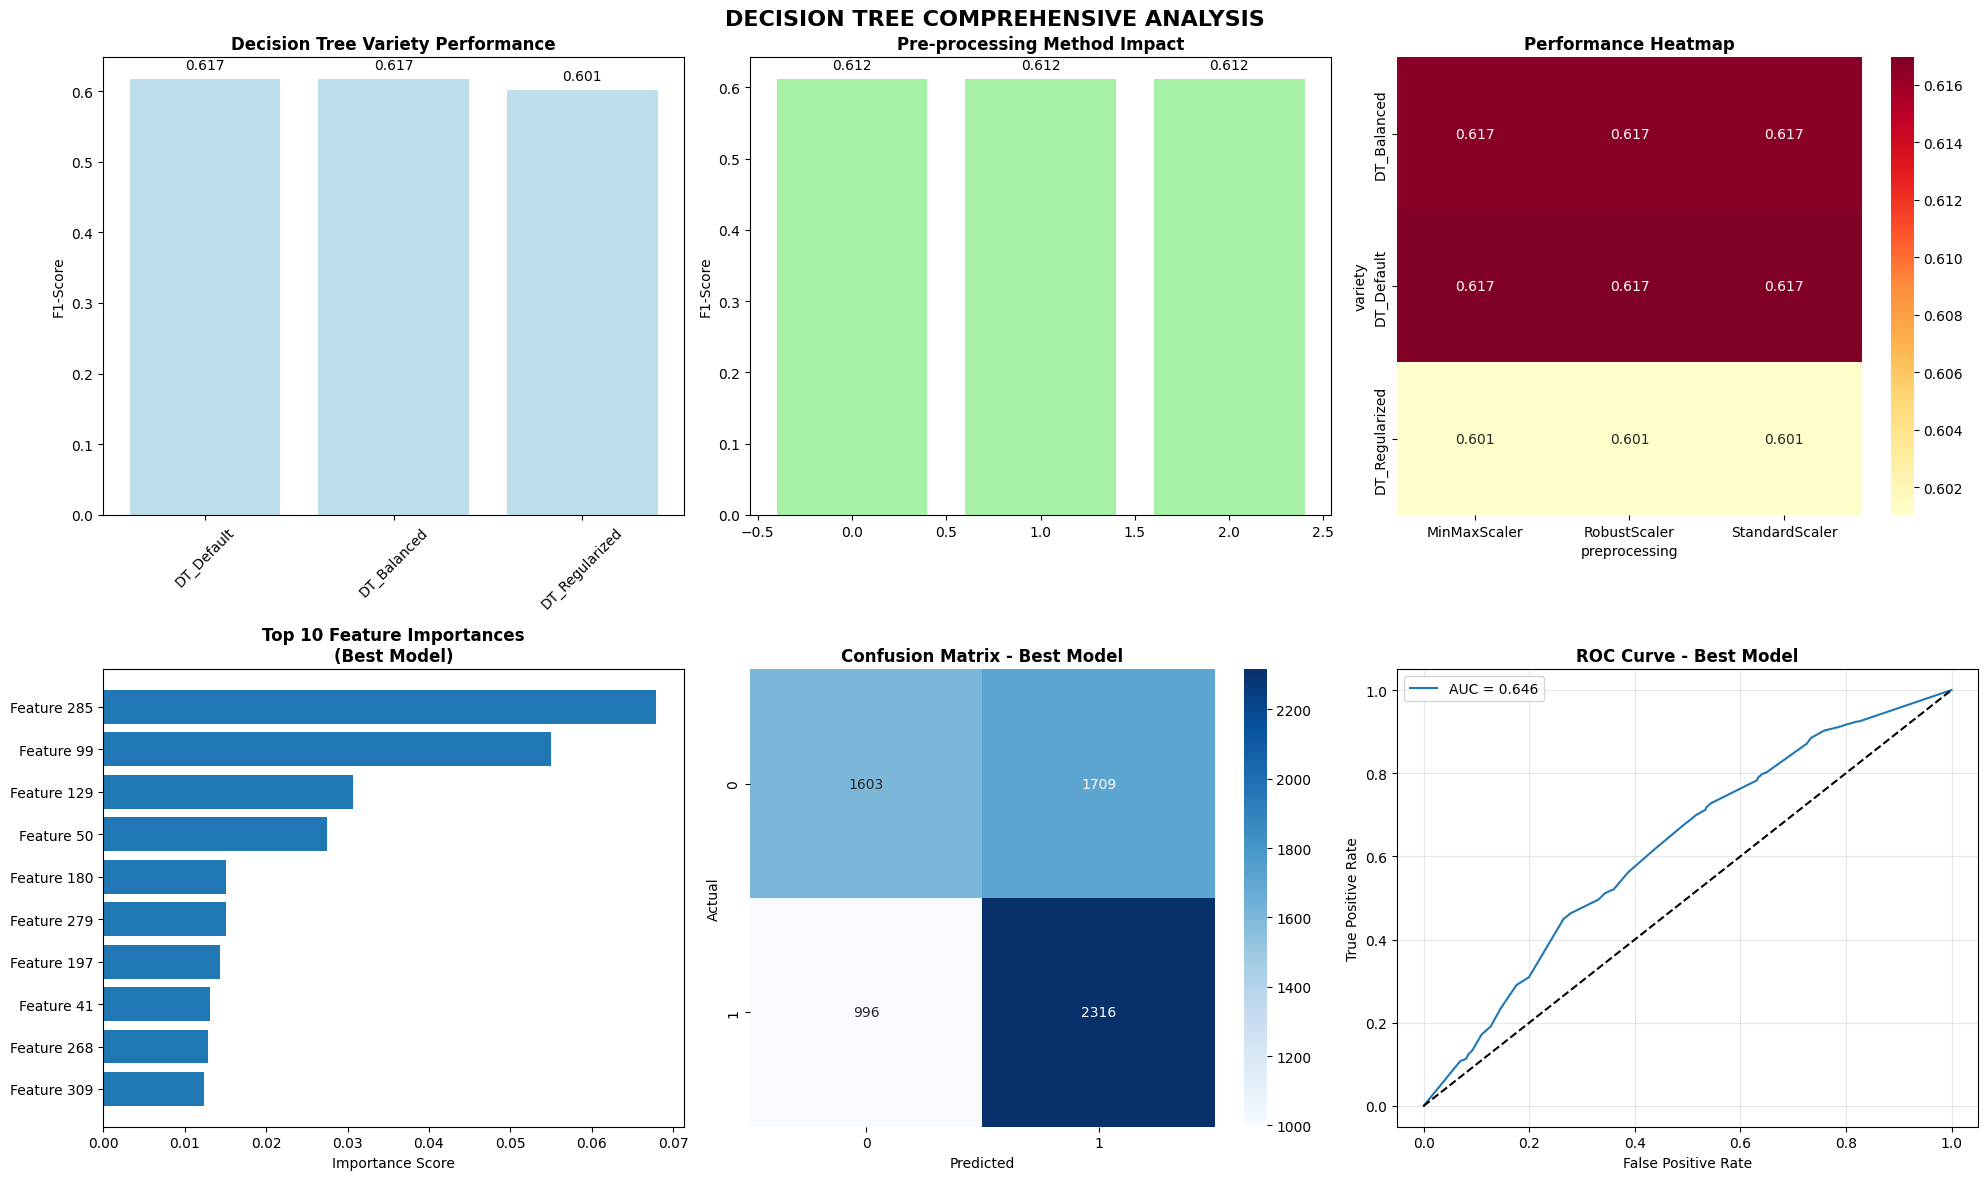

In [ ]:
# 4. VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('DECISION TREE COMPREHENSIVE ANALYSIS', fontsize=16, fontweight='bold')

# 1. Performance by Variety
variety_f1 = results_df.groupby('variety')['f1'].mean().sort_values(ascending=False)
bars1 = axes[0,0].bar(range(len(variety_f1)), variety_f1.values, color='lightblue', alpha=0.8)
axes[0,0].set_title('Decision Tree Variety Performance', fontweight='bold')
axes[0,0].set_ylabel('F1-Score')
axes[0,0].set_xticks(range(len(variety_f1)))
axes[0,0].set_xticklabels(variety_f1.index, rotation=45)
for i, v in enumerate(variety_f1.values):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Pre-processing Impact
preproc_f1 = results_df.groupby('preprocessing')['f1'].mean().sort_values(ascending=False)
bars2 = axes[0,1].bar(range(len(preproc_f1)), preproc_f1.values, color='lightgreen', alpha=0.8)
axes[0,1].set_title('Pre-processing Method Impact', fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
for i, v in enumerate(preproc_f1.values):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. Performance Heatmap
pivot_data = results_df.pivot(index='variety', columns='preprocessing', values='f1')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,2])
axes[0,2].set_title('Performance Heatmap', fontweight='bold')

# 4. Feature Importance (Best Model)
best_model = best_overall['model_object']
feature_importance = best_overall['feature_importance']
top_features = np.argsort(feature_importance)[-10:]  # Top 10 features

axes[1,0].barh(range(len(top_features)), feature_importance[top_features])
axes[1,0].set_yticks(range(len(top_features)))
axes[1,0].set_yticklabels([f'Feature {i}' for i in top_features])
axes[1,0].set_title('Top 10 Feature Importances\n(Best Model)', fontweight='bold')
axes[1,0].set_xlabel('Importance Score')

# 5. Confusion Matrix
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix - Best Model', fontweight='bold')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

# 6. ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
axes[1,2].plot(fpr, tpr, label=f'AUC = {best_overall["auc_roc"]:.3f}')
axes[1,2].plot([0, 1], [0, 1], 'k--')
axes[1,2].set_xlabel('False Positive Rate')
axes[1,2].set_ylabel('True Positive Rate')
axes[1,2].set_title('ROC Curve - Best Model', fontweight='bold')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 5. COMPREHENSIVE EXPLANATION

print(f""" Best Model:
   • Best Performing: {best_overall['variety']} with {best_overall['preprocessing']}
   • Key Finding: {variety_performance.index[0]} performed most consistently
   • Performance Range: F1-Scores from {results_df['f1'].min():.3f} to {results_df['f1'].max():.3f} """)

 Best Model:
   • Best Performing: DT_Default with StandardScaler
   • Key Finding: DT_Balanced performed most consistently
   • Performance Range: F1-Scores from 0.601 to 0.617 


In [ ]:
# 6. MODEL SAVING

joblib.dump(best_overall['model_object'], 'best_decision_tree.pkl')
print(" Best model saved as 'best_decision_tree.pkl'")

print("\n DECISION TREE ANALYSIS COMPLETED SUCCESSFULLY!")

 Best model saved as 'best_decision_tree.pkl'

 DECISION TREE ANALYSIS COMPLETED SUCCESSFULLY!
